In [11]:
import os
import numpy as np
import pandas as pd
import fastf1

cache_dir = os.path.join(os.getcwd(), "f1_cache")
os.makedirs(cache_dir, exist_ok=True)
fastf1.Cache.enable_cache(cache_dir)
pd.set_option('display.max_columns', None)

fastf1.set_log_level('DEBUG')
pd.set_option("display.max_rows", None)

In [99]:
fastf1.Cache.offline_mode(True)
corners = []
seasons = [2019, 2020, 2021, 2022, 2024, 2025, 2026]

ANGLE_THRESHOLD = 0.03
SMOOTH_WINDOW   = 5
MIN_CORNER_PTS  = 4
GAP_TOLERANCE   = 3

def close_corner(pts, direction, corners, rnd, name, driver, corner_num, season):
    if len(pts) >= MIN_CORNER_PTS:
        corner_num += 1
        corners.append({
            "Season": season,
            "RoundNumber": rnd,
            "GrandPrix": name,
            "Driver": driver,
            "CornerNumber": corner_num,
            "Direction": "Left" if direction > 0 else "Right",
            "CornerData": pts
        })
    return corner_num

try:
    for season in seasons:
        try:
            events = fastf1.get_event_schedule(season)
        except Exception as e:
            print(f"ERROR loading schedule for {season}: {e}")
            continue  # Season is skipped

        for _, erow in events.iterrows():
            rnd = erow["RoundNumber"]
            name = erow["EventName"]

            try:
                session = fastf1.get_session(season, rnd, 'Q')
                session.load()
                fastest_lap = session.laps.pick_fastest()
                driver = fastest_lap['Driver']
                telemetry = fastest_lap.get_telemetry()

                dx = telemetry["X"].diff()
                dy = telemetry["Y"].diff()
                # Finds the direction of the car in radians
                heading = np.arctan2(dy, dx)
                heading = pd.Series(np.unwrap(heading.bfill()), index=telemetry.index)
                telemetry["dheading"] = (
                    heading.diff().fillna(0)
                    .rolling(SMOOTH_WINDOW, center=True, min_periods=1).mean()
                )

                corner = []
                corner_num = 0
                in_corner = False
                current_sign = 0
                below_streak = 0

                for _, trow in telemetry.iterrows():
                    dh = trow["dheading"]
                    sign = 1 if dh > ANGLE_THRESHOLD else (-1 if dh < -ANGLE_THRESHOLD else 0)
                    pt = {"X": trow["X"], "Y": trow["Y"]}

                    if sign != 0:
                        if not in_corner:
                            in_corner = True
                            current_sign = sign
                            corner = [pt]
                            below_streak = 0
                        elif sign == current_sign:
                            corner.append(pt)
                            below_streak = 0
                        else:
                            corner_num = close_corner(corner, current_sign, corners, rnd, name, driver, corner_num, season)
                            corner = [pt]
                            current_sign = sign
                            below_streak = 0
                    elif in_corner:
                        below_streak += 1
                        corner.append(pt)
                        if below_streak > GAP_TOLERANCE:
                            trimmed = corner[:-below_streak]
                            corner_num = close_corner(trimmed, current_sign, corners, rnd, name, driver, corner_num, season)
                            in_corner = False
                            corner = []
                            current_sign = 0
                            below_streak = 0

                if in_corner and corner:
                    trimmed = corner[:-below_streak] if below_streak else corner
                    corner_num = close_corner(trimmed, current_sign, corners, rnd, name, driver, corner_num, season)

            except Exception as e:
                print(f"ERROR {rnd}: {name}: {e}")
                corners.append({
                    "Season": season,
                    "RoundNumber": rnd,
                    "GrandPrix": name,
                    "Driver": None,
                    "CornerNumber": None,
                    "Direction": None,
                    "CornerData": None
                })

except KeyboardInterrupt:
    print("Interrupted — saving what's collected so far.")

finally:
    corners_df = pd.DataFrame(corners)
    corners_df.to_pickle("corners_partial.pkl")
    print(f"Saved {len(corners_df)} rows to corners_partial.pkl")

print(corners_df)

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '77', '5', '33', '16', '8', '20', '4', '7', '11', '27', '3', '23', '99', '26', '18', '10', '55', '63', '88']
core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using c

ERROR 0: Pre-Season Test 1: Cannot get testing event by round number!
ERROR 0: Pre-Season Test 2: Cannot get testing event by round number!


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['77', '44', '33', '4', '23', '11', '16', '55', '18', '3', '5', '10', '26', '31', '8', '20', '63', '99', '7', '6']
core           INFO 	Loading data for Styrian Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
re

ERROR 0: Pre-Season Test: Cannot get testing event by round number!


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['33', '44', '77', '16', '10', '3', '4', '55', '14', '18', '11', '99', '22', '7', '63', '31', '6', '5', '47', '9']
core           INFO 	Loading data for Emilia Romagna Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '44'
core        WARNING 	Fixed i

...

ERROR 0: Pre-Season Testing: Cannot get testing event by round number!
ERROR 0: Pre-Season Testing: Cannot get testing event by round number!


core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '6', '16', '81', '1', '44', '30', '41', '5', '27', '87', '31', '10', '23', '43', '14', '11', '77', '18', '3', '55']
core           INFO 	Loading data for Chinese Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cach

ERROR 15: Azerbaijan Grand Prix: The data you are trying to access has not been loaded yet. See `Session.load`
ERROR 16: Bahrain Grand Prix: The data you are trying to access has not been loaded yet. See `Session.load`
ERROR 17: Singapore Grand Prix: The data you are trying to access has not been loaded yet. See `Session.load`
ERROR 18: United States Grand Prix: The data you are trying to access has not been loaded yet. See `Session.load`
ERROR 19: Mexico City Grand Prix: The data you are trying to access has not been loaded yet. See `Session.load`
ERROR 20: São Paulo Grand Prix: The data you are trying to access has not been loaded yet. See `Session.load`


logger      WARNING 	Failed to load track status data!
logger        DEBUG 	Traceback for failure in track status data
Traceback (most recent call last):
  File "/home/jwoodward/code/Identifying-Corners/.venv/lib/python3.10/site-packages/fastf1/logger.py", line 112, in __wrapped
    return func(*args, **kwargs)
  File "/home/jwoodward/code/Identifying-Corners/.venv/lib/python3.10/site-packages/fastf1/core.py", line 2105, in _load_track_status_data
    track_status = api.track_status_data(self.api_path, livedata=livedata)
  File "/home/jwoodward/code/Identifying-Corners/.venv/lib/python3.10/site-packages/fastf1/req.py", line 459, in _cached_api_request
    data = func(api_path, **func_kwargs)
  File "/home/jwoodward/code/Identifying-Corners/.venv/lib/python3.10/site-packages/fastf1/_api.py", line 1306, in track_status_data
    raise SessionNotAvailableError(
fastf1._api.SessionNotAvailableError: No data for this session! If this session only finished recently, please try again in a few 

ERROR 21: Las Vegas Grand Prix: The data you are trying to access has not been loaded yet. See `Session.load`
ERROR 22: Qatar Grand Prix: The data you are trying to access has not been loaded yet. See `Session.load`
ERROR 23: Abu Dhabi Grand Prix: The data you are trying to access has not been loaded yet. See `Session.load`
Saved 2280 rows to corners_partial.pkl
      Season  RoundNumber                    GrandPrix Driver  CornerNumber  \
0       2019            1        Australian Grand Prix    HAM           1.0   
1       2019            1        Australian Grand Prix    HAM           2.0   
2       2019            1        Australian Grand Prix    HAM           3.0   
3       2019            1        Australian Grand Prix    HAM           4.0   
4       2019            1        Australian Grand Prix    HAM           5.0   
5       2019            1        Australian Grand Prix    HAM           6.0   
6       2019            1        Australian Grand Prix    HAM           7.0   
7  

In [100]:
corner_numbers = corners_df.groupby(["Season", "RoundNumber", "GrandPrix"])["CornerNumber"].max().reset_index().rename(columns={"CornerNumber": "NumCorners"})
corner_numbers[
    corner_numbers.groupby("GrandPrix")["NumCorners"].transform("nunique") > 1
].sort_values(["GrandPrix", "Season"]).reset_index(drop=True)


,Season,RoundNumber,GrandPrix,NumCorners
0,2019,21,Abu Dhabi Grand Prix,21.0
1,2020,17,Abu Dhabi Grand Prix,20.0
2,2021,22,Abu Dhabi Grand Prix,12.0
3,2022,22,Abu Dhabi Grand Prix,12.0
4,2024,24,Abu Dhabi Grand Prix,13.0
5,2025,24,Abu Dhabi Grand Prix,11.0
6,2026,23,Abu Dhabi Grand Prix,NaN
7,2019,1,Australian Grand Prix,18.0
8,2022,3,Australian Grand Prix,18.0
9,2024,3,Australian Grand Prix,20.0


In [ ]:
import matplotlib.pyplot as plt

# Find Track
target_name = "Dutch Grand Prix"
season = 2024
event = corners_df[(corners_df["GrandPrix"] == target_name) & (corners_df["Season"] == season) & (corners_df["CornerData"].notna())].dropna(subset=["RoundNumber"]).iloc[0]
rnd = event["RoundNumber"]
name = event["GrandPrix"]


dir = f"plots/corners/{name.replace(' ', '_').replace('_Grand_Prix', '')}"
os.makedirs(dir, exist_ok=True)


# Draw the full track from the fastest lap
session = fastf1.get_session(season, rnd, 'Q')
session.load()
fastest_lap = session.laps.pick_fastest()
telemetry = fastest_lap.get_telemetry()

track_corners = corners_df[
    (corners_df["RoundNumber"] == rnd)
    & (corners_df["Season"] == season)
    & corners_df["CornerData"].notna()
]

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")

# Track outline
ax.plot(telemetry["X"], telemetry["Y"], color="#c3c2b7", linewidth=2, zorder=1, solid_capstyle="round")

# Corner points + number labels
for _, crow in track_corners.iterrows():
    pts = pd.DataFrame(crow["CornerData"])
    if pts.empty:
        continue
    cx, cy = pts["X"].mean(), pts["Y"].mean()
    ax.scatter(pts["X"], pts["Y"], s=18, color="#2a78d6", zorder=2, edgecolors="none")
    ax.annotate(
        str(int(crow["CornerNumber"])),
        (cx, cy),
        textcoords="offset points", xytext=(6, 6),
        fontsize=10, fontweight="bold", color="#0b0b0b", zorder=3,
    )

ax.set_aspect("equal")
ax.set_title(
    f"{name} {season} — Corner Numbers ({event['Driver']}'s fastest Q lap)",
    color="#0b0b0b", fontsize=13,
)
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{dir}/{season}_corners.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
target_name = "British Grand Prix"
season = 2021
track = corners_df[(corners_df["Season"] == season) & (corners_df["GrandPrix"] == target_name)]

corners = list(track['CornerData'])
for corner in corners:
    print(corner)
circle_points = []
for i in range(len(corners)):
    p1 = corners[i][0].values()
    p2 = corners[i][int(len(corners[i])/2)].values()
    p3 = corners[i][-1].values()
    circle_points.append([p1, p2, p3])

circle_points
import math

def circle_from_3_points(p1, p2, p3):
    """
    Finds the center, radius, and equation of a circle passing through three points.
    p1, p2, p3 are tuples/lists of (x, y) coordinates.
    """
    x1, y1 = p1
    x2, y2 = p2
    x3, y3 = p3

    # Calculate the determinant
    det = (x1 - x2) * (y2 - y3) - (x2 - x3) * (y1 - y2)
    
    # If determinant is zero, the points are collinear (lie on a straight line)
    if abs(det) < 1e-10:
        raise ValueError("The points are collinear; a circle cannot be formed.")

    # Intermediate squared values
    sq1 = x1**2 + y1**2
    sq2 = x2**2 + y2**2
    sq3 = x3**2 + y3**2

    # Determinants for center coordinates (h, k)
    # Using Cramer's rule variants derived from perpendicular bisectors
    bc = (sq1 - sq2) / 2
    cd = (sq2 - sq3) / 2

    # Center coordinates (h, k)
    h = (bc * (y2 - y3) - cd * (y1 - y2)) / det
    k = ((x1 - x2) * cd - (x2 - x3) * bc) / det

    # Radius r is the distance from the center to any of the three points
    r = math.sqrt((x1 - h)**2 + (y1 - k)**2)

    # Standard form equation string
    equation = f"(x - {h:.2f})^2 + (y - {k:.2f})^2 = {r**2:.2f}"

    return (h, k), r, equation
corner_eqns = []
for p1, p2, p3 in circle_points:
    (h, k), r, _ = circle_from_3_points(p1, p2, p3)
    corner_eqns.append(((h, k), r))

corner_eqns
    


,Season,RoundNumber,GrandPrix,Driver,CornerNumber,Direction,CornerData
747,2021,10,British Grand Prix,HAM,1.0,Right,"[{'X': 377.0, 'Y': 4095.0}, {'X': 443.27984798..."
748,2021,10,British Grand Prix,HAM,2.0,Left,"[{'X': 2338.679653939809, 'Y': 4439.1568892708..."
749,2021,10,British Grand Prix,HAM,3.0,Right,"[{'X': 4654.0, 'Y': 5822.0}, {'X': 4674.934852..."
750,2021,10,British Grand Prix,HAM,4.0,Left,"[{'X': 5405.0, 'Y': 5166.0}, {'X': 5417.749130..."
751,2021,10,British Grand Prix,HAM,5.0,Left,"[{'X': 6311.72670290246, 'Y': 5657.20287578065..."
752,2021,10,British Grand Prix,HAM,6.0,Left,"[{'X': 1650.2571157513048, 'Y': 10655.02973196..."
753,2021,10,British Grand Prix,HAM,7.0,Right,"[{'X': 177.0, 'Y': 9985.0}, {'X': 159.16836351..."
754,2021,10,British Grand Prix,HAM,8.0,Right,"[{'X': 728.0, 'Y': 12339.0}, {'X': 735.7713828..."
755,2021,10,British Grand Prix,HAM,9.0,Right,"[{'X': 5179.449153594554, 'Y': 13115.508520458..."
756,2021,10,British Grand Prix,HAM,10.0,Right,"[{'X': 7489.146326928217, 'Y': 7255.1127190431..."


In [187]:
# Fit a circle to every corner of every track/season and save to a file.
# X/Y are FastF1 units (1/10 m), so CenterX/CenterY/Radius are in decimetres.
rows = []
for _, crow in corners_df[corners_df["CornerData"].notna()].iterrows():
    pts = crow["CornerData"]
    p1, p2, p3 = (tuple(pts[i].values()) for i in (0, len(pts) // 2, -1))
    try:
        (cx, cy), radius, eqn = circle_from_3_points(p1, p2, p3)
    except ValueError:  # collinear points, no circle
        cx = cy = radius = float("nan")
        eqn = None
    rows.append({
        "Season": crow["Season"],
        "RoundNumber": crow["RoundNumber"],
        "GrandPrix": crow["GrandPrix"],
        "CornerNumber": crow["CornerNumber"],
        "Direction": crow["Direction"],
        "CenterX": cx,
        "CenterY": cy,
        "Radius": radius,
        "Equation": eqn,
    })

corner_circles_df = pd.DataFrame(rows)
corner_circles_df.to_csv("corner_circles.csv", index=False)
print(f"Saved {len(corner_circles_df)} corner circles "
      f"({corner_circles_df['Radius'].isna().sum()} collinear/skipped) to corner_circles.csv")
corner_circles_df

Saved 2262 corner circles (1 collinear/skipped) to corner_circles.csv


,Season,RoundNumber,GrandPrix,CornerNumber,Direction,CenterX,CenterY,Radius,Equation
0,2019,1,Australian Grand Prix,1.0,Right,-3482.093472,1252.001936,248.366444,(x - -3482.09)^2 + (y - 1252.00)^2 = 61685.89
1,2019,1,Australian Grand Prix,2.0,Left,-4764.761805,1971.560658,1261.601639,(x - -4764.76)^2 + (y - 1971.56)^2 = 1591638.70
2,2019,1,Australian Grand Prix,3.0,Right,-7030.526764,7043.462630,216.711359,(x - -7030.53)^2 + (y - 7043.46)^2 = 46963.81
3,2019,1,Australian Grand Prix,4.0,Left,-6210.329353,7812.902070,383.248556,(x - -6210.33)^2 + (y - 7812.90)^2 = 146879.46
4,2019,1,Australian Grand Prix,5.0,Right,-5362.548971,9520.647444,571.648176,(x - -5362.55)^2 + (y - 9520.65)^2 = 326781.64
5,2019,1,Australian Grand Prix,6.0,Right,-2303.606513,11420.292606,449.955849,(x - -2303.61)^2 + (y - 11420.29)^2 = 202460.27
6,2019,1,Australian Grand Prix,7.0,Left,-904.501701,13065.482837,1757.187748,(x - -904.50)^2 + (y - 13065.48)^2 = 3087708.78
7,2019,1,Australian Grand Prix,8.0,Right,-988.707470,9366.702719,1957.776227,(x - -988.71)^2 + (y - 9366.70)^2 = 3832887.75
8,2019,1,Australian Grand Prix,9.0,Right,1176.138611,7424.250441,247.741365,(x - 1176.14)^2 + (y - 7424.25)^2 = 61375.78
9,2019,1,Australian Grand Prix,10.0,Left,1459.493202,6282.667078,948.492666,(x - 1459.49)^2 + (y - 6282.67)^2 = 899638.34


In [ ]:
import matplotlib.pyplot as plt

# Find Track
event = corners_df[(corners_df["GrandPrix"] == target_name) & (corners_df["Season"] == season) & (corners_df["CornerData"].notna())].dropna(subset=["RoundNumber"]).iloc[0]
rnd = event["RoundNumber"]
name = event["GrandPrix"]


dir = f"plots/corners/{name.replace(' ', '_').replace('_Grand_Prix', '')}"
os.makedirs(dir, exist_ok=True)


# Draw the full track from the fastest lap
session = fastf1.get_session(season, rnd, 'Q')
session.load()
fastest_lap = session.laps.pick_fastest()
telemetry = fastest_lap.get_telemetry()

track_corners = corners_df[
    (corners_df["RoundNumber"] == rnd)
    & (corners_df["Season"] == season)
    & corners_df["CornerData"].notna()
]

# Extent of the track + every circle
xmin, xmax = telemetry["X"].min(), telemetry["X"].max()
ymin, ymax = telemetry["Y"].min(), telemetry["Y"].max()
for (x, y), r in corner_eqns:
    xmin, xmax = min(xmin, x - r), max(xmax, x + r)
    ymin, ymax = min(ymin, y - r), max(ymax, y + r)

pad = 0.05 * max(xmax - xmin, ymax - ymin)
xmin, xmax, ymin, ymax = xmin - pad, xmax + pad, ymin - pad, ymax + pad

# Figure shaped like the data, so equal aspect doesn't shrink it
w, h = xmax - xmin, ymax - ymin
long_side = 16
figsize = (long_side, long_side * h / w) if w >= h else (long_side * w / h, long_side)

fig, ax = plt.subplots(figsize=figsize)



fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")

# Track outline
ax.plot(telemetry["X"], telemetry["Y"], color="#c3c2b7", linewidth=2, zorder=1, solid_capstyle="round")

# Corner points + number labels
for _, crow in track_corners.iterrows():
    pts = pd.DataFrame(crow["CornerData"])
    if pts.empty:
        continue
    cx, cy = pts["X"].mean(), pts["Y"].mean()
    ax.scatter(pts["X"], pts["Y"], s=18, color="#2a78d6", zorder=2, edgecolors="none")
    ax.annotate(
        str(int(crow["CornerNumber"])),
        (cx, cy),
        textcoords="offset points", xytext=(6, 6),
        fontsize=10, fontweight="bold", color="#0b0b0b", zorder=3,
    )

for (x, y), r in corner_eqns:
    circle = plt.Circle((x, y), r, color="#d62a2a", fill=False, linewidth=1.5, zorder=4)
    ax.add_artist(circle)
    # ax.annotate(
    #     f"{r/10:.2f}",
    #     (x, y),
    #     textcoords="offset points", xytext=(6, 6),
    #     fontsize=10, fontweight="bold", color="#0b0b0b", zorder=3, ha="center", va="center"
    # )

ax.set_aspect("equal")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_title(
    f"{name} {season} — Corner Numbers ({event['Driver']}'s fastest Q lap)",
    color="#0b0b0b", fontsize=13,
)
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{dir}/{season}_corner_radii.png", dpi=300, bbox_inches="tight")
plt.show()

In [184]:
fastf1.Cache.offline_mode(False)
circuits = fastf1.ergast.Ergast().get_circuits(limit=1000)
circuits

,circuitId,circuitUrl,circuitName,lat,long,locality,country
0,adelaide,https://en.wikipedia.org/wiki/Adelaide_Street_...,Adelaide Street Circuit,-34.92720,138.617000,Adelaide,Australia
1,ain-diab,https://en.wikipedia.org/wiki/Ain-Diab_Circuit,Ain Diab,33.57860,-7.687500,Casablanca,Morocco
2,aintree,https://en.wikipedia.org/wiki/Aintree_Motor_Ra...,Aintree,53.47690,-2.940560,Liverpool,UK
3,albert_park,https://en.wikipedia.org/wiki/Albert_Park_Circuit,Albert Park Grand Prix Circuit,-37.84970,144.968000,Melbourne,Australia
4,americas,https://en.wikipedia.org/wiki/Circuit_of_the_A...,Circuit of the Americas,30.13280,-97.641100,Austin,USA
5,anderstorp,https://en.wikipedia.org/wiki/Anderstorp_Raceway,Scandinavian Raceway,57.26530,13.604200,Anderstorp,Sweden
6,avus,https://en.wikipedia.org/wiki/AVUS,AVUS,52.48060,13.251400,Berlin,Germany
7,bahrain,https://en.wikipedia.org/wiki/Bahrain_Internat...,Bahrain International Circuit,26.03250,50.510600,Sakhir,Bahrain
8,baku,https://en.wikipedia.org/wiki/Baku_City_Circuit,Baku City Circuit,40.37250,49.853300,Baku,Azerbaijan
9,boavista,https://en.wikipedia.org/wiki/Circuito_da_Boav...,Circuito da Boavista,41.17050,-8.673250,Oporto,Portugal


core           INFO 	Loading data for British Grand Prix - Qualifying [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '33', '77', '16', '11', '4', '3', '63', '55', '5', '14', '10', '31', '99', '18', '22', '7', '6', '47', '9']


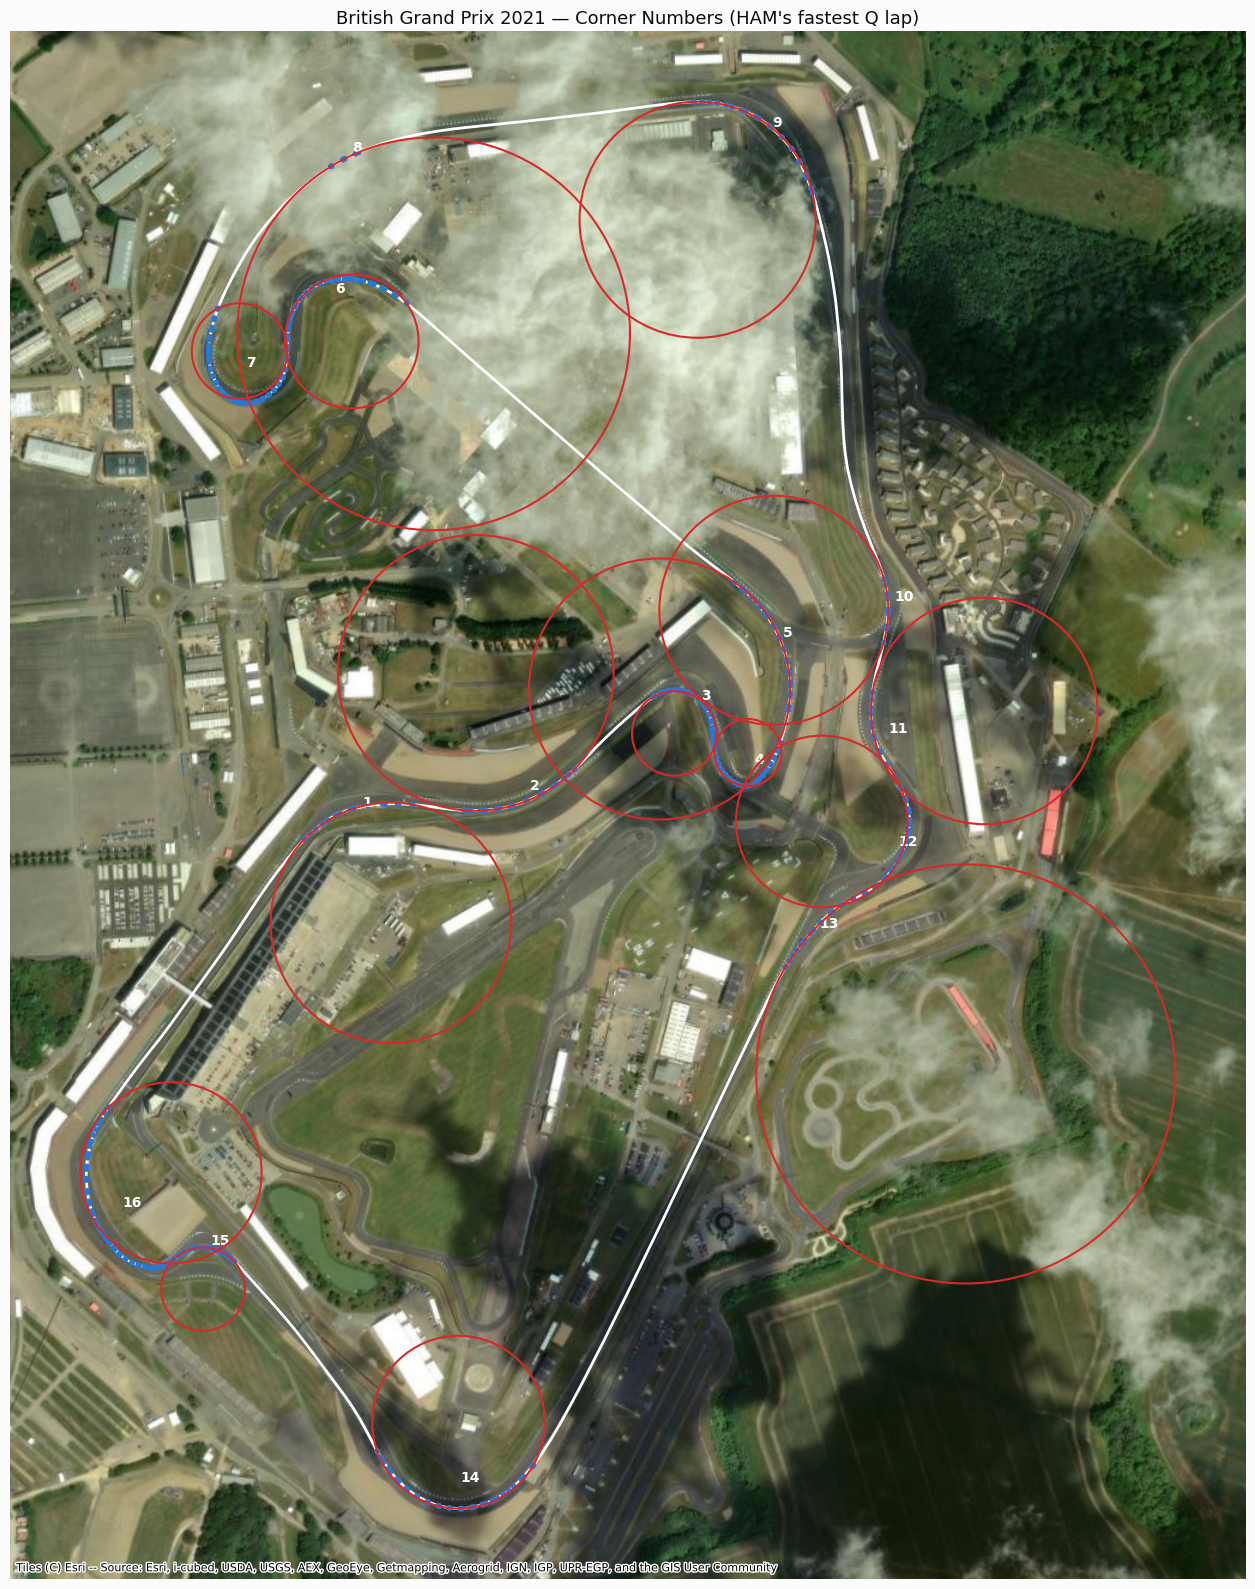

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from pyproj import Transformer

# --- Georeferencing (tune theta / dx / dy until the outline sits on the tarmac) ---
circ = fastf1.ergast.Ergast().get_circuits(season=season, round=int(rnd)).iloc[0]
lat0, lon0 = circ["lat"], circ["long"]
import json
G = json.load(open("georef.json"))[circ["circuitId"]]
g = {**G, **G.get("by_season", {}).get(str(season), {})}
theta, dx, dy = g["theta"], g["dx"], g["dy"]
basemap = ctx.providers.Esri.WorldImagery
zoom = 16

# Find Track
event = corners_df[(corners_df["GrandPrix"] == target_name) & (corners_df["Season"] == season) & (corners_df["CornerData"].notna())].dropna(subset=["RoundNumber"]).iloc[0]
rnd = event["RoundNumber"]
name = event["GrandPrix"]


dir = f"plots/maps/{name.replace(' ', '_').replace('_Grand_Prix', '')}"
os.makedirs(dir, exist_ok=True)


# Draw the full track from the fastest lap
session = fastf1.get_session(season, rnd, 'Q')
session.load()
fastest_lap = session.laps.pick_fastest()
telemetry = fastest_lap.get_telemetry()

track_corners = corners_df[
    (corners_df["RoundNumber"] == rnd)
    & (corners_df["Season"] == season)
    & corners_df["CornerData"].notna()
]

# Decimeters to meters
zone = int((lon0 + 180) // 6) + 1
utm_crs = f"EPSG:{(32600 if lat0 >= 0 else 32700) + zone}"
ox, oy = Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True).transform(lon0, lat0)

X0 = (telemetry["X"].min() + telemetry["X"].max()) / 2
Y0 = (telemetry["Y"].min() + telemetry["Y"].max()) / 2
rot = np.radians(theta)

def place(x, y):
    x = (np.asarray(x, dtype=float) - X0) / 10
    y = (np.asarray(y, dtype=float) - Y0) / 10
    return (ox + dx + x * np.cos(rot) - y * np.sin(rot),
            oy + dy + x * np.sin(rot) + y * np.cos(rot))

tx, ty = place(telemetry["X"], telemetry["Y"])
circles = [(*place(x, y), r / 10) for (x, y), r in corner_eqns]   # (cx, cy, radius in metres)

# Extent of the track + every circle
xmin, xmax = tx.min(), tx.max()
ymin, ymax = ty.min(), ty.max()
for ccx, ccy, cr in circles:
    xmin, xmax = min(xmin, ccx - cr), max(xmax, ccx + cr)
    ymin, ymax = min(ymin, ccy - cr), max(ymax, ccy + cr)

pad = 0.05 * max(xmax - xmin, ymax - ymin)
xmin, xmax, ymin, ymax = xmin - pad, xmax + pad, ymin - pad, ymax + pad

long_side = 16
figsize = (long_side, long_side * h / w) if w >= h else (long_side * w / h, long_side)

fig, ax = plt.subplots(figsize=figsize)

fig.patch.set_facecolor("#fcfcfb")
ax.set_facecolor("#fcfcfb")

# Track outline
ax.plot(tx, ty, color="#ffffff", linewidth=2, zorder=1, solid_capstyle="round")

# Corner points + number labels
for _, crow in track_corners.iterrows():
    pts = pd.DataFrame(crow["CornerData"])
    if pts.empty:
        continue
    px, py = place(pts["X"], pts["Y"])
    cx, cy = px.mean(), py.mean()
    ax.scatter(px, py, s=18, color="#2a78d6", zorder=2, edgecolors="none")
    ax.annotate(
        str(int(crow["CornerNumber"])),
        (cx, cy),
        textcoords="offset points", xytext=(6, 6),
        fontsize=10, fontweight="bold", color="#ffffff", zorder=3,
    )

for ccx, ccy, cr in circles:
    circle = plt.Circle((ccx, ccy), cr, color="#d62a2a", fill=False, linewidth=1.5, zorder=4)
    ax.add_artist(circle)
    # ax.annotate(
    #     f"{cr:.2f}",
    #     (ccx, ccy),
    #     fontsize=10, fontweight="bold", color="#0b0b0b", zorder=3, ha="center", va="center"
    # )

ax.set_aspect("equal")
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

# Basemap must come after the limits are set
ctx.add_basemap(ax, crs=utm_crs, source=basemap, zoom=zoom)

ax.set_title(
    f"{name} {season} — Corner Numbers ({event['Driver']}'s fastest Q lap)",
    color="#0b0b0b", fontsize=13,
)
ax.axis("off")
plt.tight_layout()
plt.savefig(f"{dir}/{season}_map_corner_radii.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
from pyproj import Transformer

MAP_DIR = "plots/maps"
OVERWRITE = False              # False = skip images that already exist (lets you resume)
BASEMAP = ctx.providers.Esri.WorldImagery
ZOOM = 16
TILE_RETRIES = 6
JPEG_QUALITY = 85              # satellite imagery is ~10x smaller as JPEG than PNG
EXTENT_MAX_RADIUS_M = 500      # bigger "circles" are near-straights; drawn but don't stretch the map

georef = json.load(open("georef.json"))
event_circuits = json.load(open("event_circuits.json"))   # "season-round" -> circuitId, lat, long


def plot_event_map(season, rnd, out_root=MAP_DIR):
    track_corners = corners_df[
        (corners_df["Season"] == season)
        & (corners_df["RoundNumber"] == rnd)
        & corners_df["CornerData"].notna()
    ]
    name = track_corners["GrandPrix"].iloc[0]
    driver = track_corners["Driver"].iloc[0]

    out_dir = f"{out_root}/{name.replace(' ', '_').replace('_Grand_Prix', '')}"
    out_path = f"{out_dir}/{season}_map_corner_radii.jpg"
    if os.path.exists(out_path) and not OVERWRITE:
        return "skipped (exists)"
    os.makedirs(out_dir, exist_ok=True)

    # --- Georeferencing (theta / dx / dy from georef.json) ---
    circ = event_circuits[f"{season}-{rnd}"]
    lat0, lon0 = circ["lat"], circ["long"]
    G = georef[circ["circuitId"]]
    g = {**G, **G.get("by_season", {}).get(str(season), {})}
    theta, dx, dy = g["theta"], g["dx"], g["dy"]

    # Draw the full track from the fastest lap
    session = fastf1.get_session(season, rnd, 'Q')
    session.load()
    telemetry = session.laps.pick_fastest().get_telemetry()

    # Decimeters to meters
    zone = int((lon0 + 180) // 6) + 1
    utm_crs = f"EPSG:{(32600 if lat0 >= 0 else 32700) + zone}"
    ox, oy = Transformer.from_crs("EPSG:4326", utm_crs, always_xy=True).transform(lon0, lat0)

    X0 = (telemetry["X"].min() + telemetry["X"].max()) / 2
    Y0 = (telemetry["Y"].min() + telemetry["Y"].max()) / 2
    rot = np.radians(theta)

    def place(x, y):
        x = (np.asarray(x, dtype=float) - X0) / 10
        y = (np.asarray(y, dtype=float) - Y0) / 10
        return (ox + dx + x * np.cos(rot) - y * np.sin(rot),
                oy + dy + x * np.sin(rot) + y * np.cos(rot))

    tx, ty = place(telemetry["X"], telemetry["Y"])

    event_circles = corner_circles_df[
        (corner_circles_df["Season"] == season)
        & (corner_circles_df["RoundNumber"] == rnd)
    ].dropna(subset=["Radius"])
    circles = [(*place(c.CenterX, c.CenterY), c.Radius / 10) for c in event_circles.itertuples()]

    # Extent of the track + every reasonably sized circle
    xmin, xmax = tx.min(), tx.max()
    ymin, ymax = ty.min(), ty.max()
    for ccx, ccy, cr in circles:
        if cr <= EXTENT_MAX_RADIUS_M:
            xmin, xmax = min(xmin, ccx - cr), max(xmax, ccx + cr)
            ymin, ymax = min(ymin, ccy - cr), max(ymax, ccy + cr)

    pad = 0.05 * max(xmax - xmin, ymax - ymin)
    xmin, xmax, ymin, ymax = xmin - pad, xmax + pad, ymin - pad, ymax + pad

    # Figure shaped like the data, so equal aspect doesn't shrink it
    w, h = xmax - xmin, ymax - ymin
    long_side = 16
    figsize = (long_side, long_side * h / w) if w >= h else (long_side * w / h, long_side)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("#fcfcfb")
    ax.set_facecolor("#fcfcfb")

    # Track outline
    ax.plot(tx, ty, color="#ffffff", linewidth=2, zorder=1, solid_capstyle="round")

    # Corner points + number labels
    for _, crow in track_corners.iterrows():
        pts = pd.DataFrame(crow["CornerData"])
        if pts.empty:
            continue
        px, py = place(pts["X"], pts["Y"])
        ax.scatter(px, py, s=18, color="#2a78d6", zorder=2, edgecolors="none")
        ax.annotate(
            str(int(crow["CornerNumber"])),
            (px.mean(), py.mean()),
            textcoords="offset points", xytext=(6, 6),
            fontsize=10, fontweight="bold", color="#ffffff", zorder=3,
        )

    for ccx, ccy, cr in circles:
        ax.add_artist(plt.Circle((ccx, ccy), cr, color="#d62a2a", fill=False, linewidth=1.5, zorder=4))

    ax.set_aspect("equal")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Basemap must come after the limits are set
    for attempt in range(1, TILE_RETRIES + 1):   # tile server occasionally drops connections
        try:
            ctx.add_basemap(ax, crs=utm_crs, source=BASEMAP, zoom=ZOOM)
            break
        except Exception:
            if attempt == TILE_RETRIES:
                raise
            time.sleep(2 * attempt)

    ax.set_title(
        f"{name} {season} — Corner Numbers ({driver}'s fastest Q lap)",
        color="#0b0b0b", fontsize=13,
    )
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight", pil_kwargs={"quality": JPEG_QUALITY})
    plt.close(fig)
    return out_path


# Loop over every track/season that has corner data
events = (
    corners_df[corners_df["CornerData"].notna()][["Season", "RoundNumber"]]
    .drop_duplicates()
    .sort_values(["Season", "RoundNumber"])
)
for i, (season, rnd) in enumerate(events.itertuples(index=False), 1):
    try:
        status = plot_event_map(int(season), int(rnd))
    except Exception as e:
        status = f"ERROR: {e}"
    print(f"[{i}/{len(events)}] {season} R{int(rnd)}: {status}")